::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

Ported from
[`06_mcmc_diagnostics.ipynb`](https://github.com/USACE-RMC/Numerics-Python-Examples/blob/main/notebooks/06_mcmc_diagnostics.ipynb)
in the USACE-RMC Numerics-Python-Examples repository (0BSD licensed). The upstream
notebook drives the C# `Numerics.dll` through pythonnet; this version uses
`corehydropy`, whose compiled core is a validated C++ port of the same library. The
seeded data and every posterior summary below are bit-identical to the R version of
this example, which runs the same core. Posterior numbers differ slightly from the
upstream notebook because `mcmc_sample` uses the family's constraint-based uniform
priors rather than the hand-picked priors upstream; the Reproduction check at the
end says exactly what is compared and how.

## What you'll learn

- Running multiple chains and reading trace plots
- The Gelman-Rubin statistic (R-hat) and effective sample size (ESS)
- Autocorrelation and what it does to ESS
- What bad convergence looks like, side by side with a healthy run
- Handling multimodal posteriors with a mixture model
- Sampler tuning guidelines

## Why convergence matters

MCMC samplers start from arbitrary initial values, explore parameter space
stochastically, and only eventually settle into the target distribution. The
theoretical justification is the ergodic theorem: under regularity conditions the
time average of a function along the Markov chain converges to its expectation
under the stationary distribution,

$$
\frac{1}{N}\sum_{t=1}^{N}f(\theta_t) \;\xrightarrow{\;a.s.\;}\; \mathbb{E}_\pi[f(\theta)] \quad \text{as } N \to \infty
$$

where $\pi$ is the target (posterior) distribution. The guarantee is asymptotic.
For any finite run we need diagnostics to judge whether the chain has run long
enough: have the chains reached the stationary distribution, how many effectively
independent samples do we have, and was the warmup period sufficient? Only after
those checks pass can we trust conclusions drawn from the samples.

## Setup

The upstream setup cell loads the CoreCLR runtime, resolves the DLL, imports
sampler and diagnostic classes, and warns that the C# parallel chains fight
Python's GIL (every upstream example must set `sampler.ParallelizeChains = False`).
It also defines helper functions to copy samples out of the .NET chain objects.
None of that is needed here: `mcmc_sample` returns plain NumPy arrays and the
compiled core needs no interop workarounds.

In [1]:
import corehydropy as ch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Earth-tone palette used throughout
COLORS = ["#6b7f3f", "#b06a3b", "#5b7a8c", "#8c8c7a"]
print("Setup complete")

Setup complete


## Multiple chains for convergence assessment

Running multiple chains helps diagnose convergence and assess mixing:

1. Assess convergence via the R-hat statistic
2. Detect multimodal posteriors
3. More robust inference

As upstream, we draw 100 observations from a Normal(100, 15) with seed 1234 (the
port keeps the C# Mersenne Twister bit-exact, so this is the same data set the
upstream notebook fits) and sample the posterior of $\mu$ and $\sigma$ with a
random walk Metropolis-Hastings (RWMH) sampler and 4 chains. One deliberate
difference: the upstream notebook hand-picks Uniform(50, 150) and Uniform(5, 30)
priors and a unit proposal matrix, while `mcmc_sample` always uses the family's
constraint-based uniform priors (the C# `GetParameterConstraints` bounds), so the
posterior summaries here match the upstream statistically rather than
bit-for-bit.

In [2]:
true_mu, true_sigma = 100, 15
data = ch.Distribution("Normal", [true_mu, true_sigma]).random(100, seed=1234)

res = ch.mcmc_sample(
    data,
    distribution="Normal",
    sampler="RWMH",
    iterations=5000,
    warmup=1000,
    chains=4,
    seed=12345,
    initialize="MAP",
)

summary = pd.DataFrame(
    {
        "parameter": res["parameters"],
        "posterior mean": res["posterior_mean"],
        "posterior sd": res["posterior_sd"],
        "lower 95% CI": res["posterior_lower_ci"],
        "upper 95% CI": res["posterior_upper_ci"],
        "rhat": res["rhat"],
        "ess": res["ess"],
    }
)
print(f"{len(res['chains'])} chains x {res['chains'][0].shape[0]} retained draws")
summary.round(4)

4 chains x 5000 retained draws


,parameter,posterior mean,posterior sd,lower 95% CI,upper 95% CI,rhat,ess
0,µ,100.6322,1.5136,98.0935,103.1147,1.0001,9677.2836
1,σ,15.0126,1.0714,13.3552,16.8623,1.0000,9514.6583


## R-hat (Gelman-Rubin statistic)

R-hat compares within-chain and between-chain variance [[1]](#references).

| R-hat | Interpretation | Action |
|-------|----------------|--------|
| < 1.01 | Excellent convergence | Proceed |
| < 1.1 | Good convergence | Safe to use |
| 1.1 to 1.2 | Marginal | Run longer |
| >= 1.2 | Poor convergence | Investigate |

$$
\hat{R} = \sqrt{\frac{\hat{V}}{W}}, \qquad
\hat{V} = \frac{n-1}{n}W + \frac{1}{n}B
$$

where $W$ is the mean within-chain variance and $B$ is the between-chain variance.
$\hat{V}$ overestimates the target variance when chains have not converged, because
$B$ captures the extra spread from chains sitting in different regions, while $W$
underestimates it because each finite chain has explored only part of the space. At
convergence the between-chain contribution vanishes and $\hat{R} \to 1$; values
substantially above 1 mean the chains have not mixed [[2]](#references).

Common causes of high R-hat: insufficient warmup, poor mixing, a multimodal
posterior, bad initialization, or a sampler unsuited to the problem.

R-hat µ: 1.0001  (converged)
R-hat σ: 1.0000  (converged)


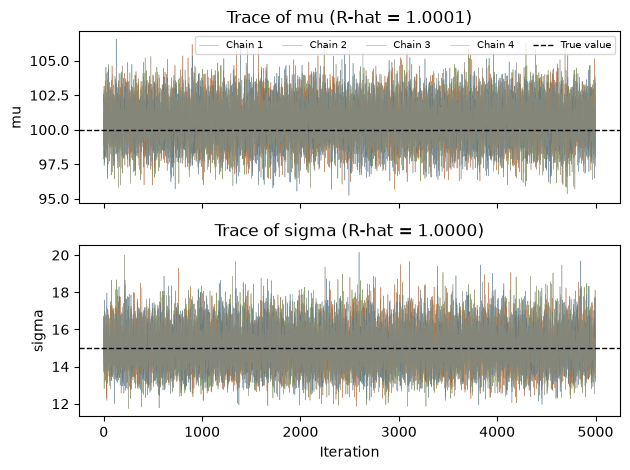

In [3]:
rhat_mu, rhat_sigma = res["rhat"]
for name, rhat in zip(res["parameters"], res["rhat"]):
    verdict = "converged" if rhat < 1.05 else "NOT converged"
    print(f"R-hat {name}: {rhat:.4f}  ({verdict})")

fig, axes = plt.subplots(2, 1, sharex=True)
for ax, j, true_val, name in [(axes[0], 0, true_mu, "mu"), (axes[1], 1, true_sigma, "sigma")]:
    for i, chain in enumerate(res["chains"]):
        ax.plot(chain[:, j], linewidth=0.4, alpha=0.7, color=COLORS[i], label=f"Chain {i + 1}")
    ax.axhline(true_val, color="black", linestyle="--", linewidth=1, label="True value")
    ax.set_ylabel(name)
    ax.set_title(f"Trace of {name} (R-hat = {res['rhat'][j]:.4f})")
axes[1].set_xlabel("Iteration")
axes[0].legend(fontsize=7, ncols=5, loc="upper right")
plt.tight_layout()
plt.show()

## Effective sample size and autocorrelation

The effective sample size (ESS) is the number of independent samples that would
give the same variance for the sample mean [[3]](#references). Higher is better,
and ESS is tied directly to autocorrelation:

$$
\text{ESS} = \frac{N}{1 + 2\sum_{k=1}^{K} \rho_k}
$$

where $\rho_k$ is the autocorrelation at lag $k$ and the sum is truncated when
$\rho_k$ becomes negligible. With $M$ chains the core computes the truncated
autocorrelation sum for each chain, averages across chains, and caps the result at
the total number of draws.

Guidelines for the smallest acceptable ESS depend on what you are estimating: about
100 for a posterior mean, 200 for a posterior standard deviation, 400 for a 95%
credible interval, and 1000 or more for tail probabilities. These are guidelines,
not strict rules; for life-safety applications err on the side of more.

| Lag-1 ACF | Interpretation | ESS impact |
|-----------|----------------|------------|
| < 0.1 | Excellent mixing | ESS close to N |
| 0.1 to 0.3 | Good mixing | ESS about 0.5 N |
| 0.3 to 0.6 | Moderate | ESS about 0.2 N |
| > 0.6 | Poor mixing | ESS well below 0.1 N |

The R-hat and ESS values come from the ported core (they are returned by
`mcmc_sample`). The C# `MCMCDiagnostics` autocorrelation helper for arbitrary
arrays is not exposed in the package API, so the cell below computes the
autocorrelation function directly with NumPy.

Effective sample size
                  Metric    Value
           Total samples 20000.00
                ESS (mu)  9677.28
   ESS efficiency (mu) %    48.39
             ESS (sigma)  9514.66
ESS efficiency (sigma) %    47.57


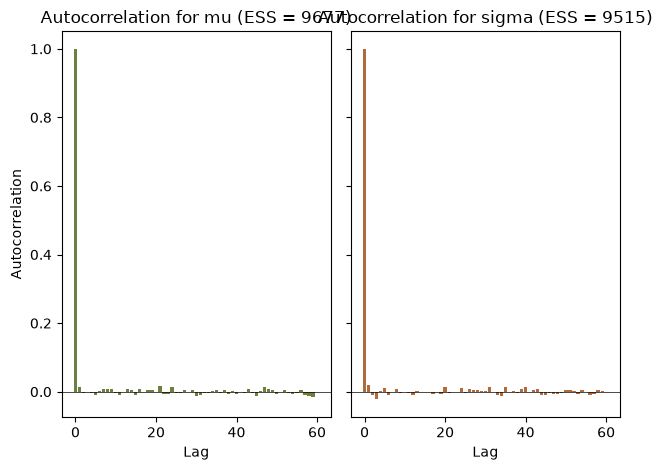

In [4]:
def acf(x, nlags):
    """Autocorrelation function, standard biased estimator (matches R's stats::acf)."""
    x = np.asarray(x) - np.mean(x)
    denom = np.dot(x, x)
    return np.array([1.0] + [np.dot(x[:-k], x[k:]) / denom for k in range(1, nlags + 1)])

combined = np.vstack(res["chains"])  # (20000, 2) pooled draws
n_total = combined.shape[0]

ess_df = pd.DataFrame(
    {
        "Metric": ["Total samples", "ESS (mu)", "ESS efficiency (mu) %",
                   "ESS (sigma)", "ESS efficiency (sigma) %"],
        "Value": [n_total, res["ess"][0], 100 * res["ess"][0] / n_total,
                  res["ess"][1], 100 * res["ess"][1] / n_total],
    }
)
print("Effective sample size")
print(ess_df.round(2).to_string(index=False))

max_lag = 60
fig, axes = plt.subplots(1, 2, sharey=True)
for ax, j, color, name in [(axes[0], 0, COLORS[0], "mu"), (axes[1], 1, COLORS[1], "sigma")]:
    ax.bar(range(max_lag + 1), acf(combined[:, j], max_lag), color=color, width=0.8)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel("Lag")
    ax.set_title(f"Autocorrelation for {name} (ESS = {res['ess'][j]:.0f})")
axes[0].set_ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

## What bad convergence looks like

The diagnostics only earn their keep when they catch a failure, so let us
manufacture one. The same model is run again with only 200 iterations, 50 warmup,
and randomized initialization (the upstream notebook's initialization choice), then
compared with the healthy 5000-iteration run.

                            Run  R-hat (mu)  R-hat (sigma)  ESS (mu)  ESS (sigma)
200 iterations, randomized init       1.585          1.197  8139.675     9197.341
      5000 iterations, MAP init       1.000          1.000  9677.284     9514.658


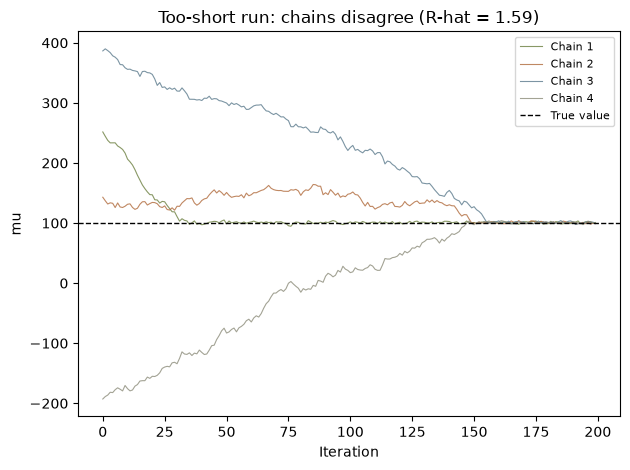

In [5]:
short = ch.mcmc_sample(
    data,
    distribution="Normal",
    sampler="RWMH",
    iterations=200,
    warmup=50,
    chains=4,
    seed=12345,
    initialize="Randomize",
)

compare = pd.DataFrame(
    {
        "Run": ["200 iterations, randomized init", "5000 iterations, MAP init"],
        "R-hat (mu)": [short["rhat"][0], res["rhat"][0]],
        "R-hat (sigma)": [short["rhat"][1], res["rhat"][1]],
        "ESS (mu)": [short["ess"][0], res["ess"][0]],
        "ESS (sigma)": [short["ess"][1], res["ess"][1]],
    }
)
print(compare.round(3).to_string(index=False))

fig, ax = plt.subplots()
for i, chain in enumerate(short["chains"]):
    ax.plot(chain[:, 0], linewidth=0.8, alpha=0.8, color=COLORS[i], label=f"Chain {i + 1}")
ax.axhline(true_mu, color="black", linestyle="--", linewidth=1, label="True value")
ax.set_xlabel("Iteration")
ax.set_ylabel("mu")
ax.set_title(f"Too-short run: chains disagree (R-hat = {short['rhat'][0]:.2f})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The short run fails the R-hat test decisively (1.59 for $\mu$ against the
1.1 threshold) and the trace plot shows the four chains still wandering in from
their random starting points. Note the trap in the ESS column: the short run
reports an ESS larger than its 800 retained draws. The truncated autocorrelation
estimator is simply unreliable on chains that have not converged, so an
impossible-looking ESS is itself a red flag. Check R-hat first; ESS is only
meaningful once R-hat passes.

## Handling multimodal posteriors

Some posteriors have multiple peaks. Population-based samplers such as DEMCz and
DEMCzs are better at exploring them.

The upstream notebook hand-rolls a five-parameter two-component Normal mixture
log-likelihood in Python and passes it to the C# DEMCz sampler as a delegate.
Custom log-likelihood delegates are not exposed in the package API, so this section
recasts the same problem onto `mixture_analysis`, which fits the same
two-component Normal mixture with the same DEMCz sampler through the ported
MixtureModel. The bimodal data are built exactly as upstream: 40 seeded draws from
Normal(80, 10) and 40 from Normal(120, 10), both with seed 789 (reusing the seed
means the second sample is the first shifted by 40, an upstream quirk we keep for
faithfulness).

One honest caveat about the comparison: the upstream run itself did not separate
the modes. Its posterior means collapsed to $\mu_1 \approx 99.4$,
$\mu_2 \approx 99.6$ with weight 0.5, the classic label-switching average. The
ported MixtureModel seeds the sampler with an expectation-maximization fit, so the
run below recovers both modes; the comparison with upstream is therefore
qualitative, not numeric.

Parameter  Estimate  True
 weight 1     0.519   0.5
 weight 2     0.481   0.5
      mu1    79.706  80.0
   sigma1    11.398  10.0
      mu2   119.206 120.0
   sigma2     9.943  10.0


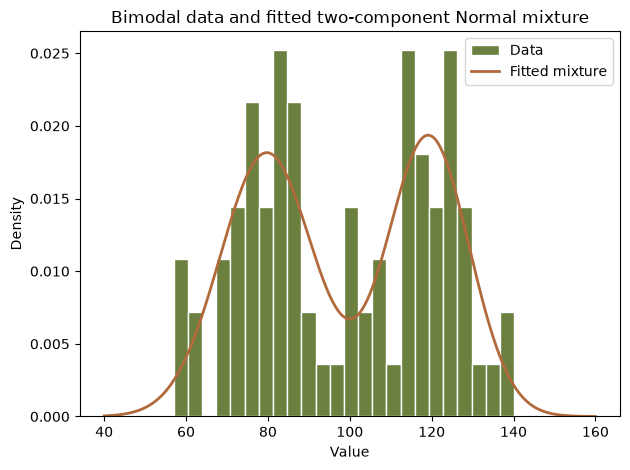

In [6]:
mode1 = ch.Distribution("Normal", [80, 10]).random(40, seed=789)
mode2 = ch.Distribution("Normal", [120, 10]).random(40, seed=789)
bimodal = np.concatenate([mode1, mode2])

mix = ch.mixture_analysis(bimodal, ["Normal", "Normal"], sampler="DEMCz",
                          iterations=3000, seed=12345)

w1, w2, mu1, s1, mu2, s2 = mix["parameters"]
est = pd.DataFrame(
    {
        "Parameter": ["weight 1", "weight 2", "mu1", "sigma1", "mu2", "sigma2"],
        "Estimate": mix["parameters"],
        "True": [0.5, 0.5, 80, 10, 120, 10],
    }
)
print(est.round(3).to_string(index=False))

x_grid = np.linspace(40, 160, 400)
pdf_fit = (w1 * ch.Distribution("Normal", [mu1, s1]).pdf(x_grid)
           + w2 * ch.Distribution("Normal", [mu2, s2]).pdf(x_grid))

fig, ax = plt.subplots()
ax.hist(bimodal, bins=24, density=True, color="#6b7f3f", edgecolor="white", label="Data")
ax.plot(x_grid, pdf_fit, color="#b06a3b", linewidth=2, label="Fitted mixture")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.set_title("Bimodal data and fitted two-component Normal mixture")
ax.legend()
plt.tight_layout()
plt.show()

## Tuning tips and best practices

General guidelines:

1. Burn-in: use 10 to 50% of total iterations
2. Sample size: aim for at least 1000 effective samples
3. Multiple chains: run 3 or 4 chains to assess convergence
4. Thinning: usually not necessary with modern samplers

Troubleshooting:

- High R-hat (> 1.1)? Increase warmup, try a different sampler, check initialization.
- Low ESS (< 100)? Increase iterations, increase thinning, or use an adaptive
  sampler (ARWMH instead of RWMH).
- Multimodal posterior? Use a population-based sampler (DEMCz, DEMCzs), check for
  model identification issues, consider transforming parameters.

Key takeaways:

1. Always check convergence: use R-hat and visual inspection.
2. ESS matters more than raw samples: account for autocorrelation.
3. Different samplers suit different problems.
4. Adaptive methods (ARWMH, DEMCz) reduce the tuning burden.
5. Multiple chains catch problems early: run at least 3 or 4.

## References

[1] A. Gelman and D. B. Rubin, "Inference from iterative simulation using multiple
sequences," *Statistical Science*, vol. 7, no. 4, pp. 457-472, 1992.

[2] A. Vehtari, A. Gelman, D. Simpson, B. Carpenter, and P.-C. Burkner,
"Rank-normalization, folding, and localization: An improved R-hat for assessing
convergence of MCMC," *Bayesian Analysis*, vol. 16, no. 2, pp. 667-718, 2021.

[3] C. J. Geyer, "Practical Markov chain Monte Carlo," *Statistical Science*,
vol. 7, no. 4, pp. 473-483, 1992.

## Reproduction check

The seeded data are bit-exact against the C# library (same Mersenne Twister
stream, enforced by the port's fixture suite) and against the R twin. The
posterior summaries cannot be compared bit-for-bit with the upstream notebook
because `mcmc_sample` uses the family's constraint-based uniform priors while
upstream hand-picks Uniform(50, 150) and Uniform(5, 30) plus a unit proposal
matrix, so those rows are held to the statistical criteria the upstream numbers
themselves satisfy. The mixture row is a recast (see above): upstream's own run
collapsed to the label-switching average, so the check here is that the recast
recovers the modes the data were generated from.

| Quantity | Upstream C# | This port | Status |
|----------|-------------|----------:|--------|
| First seeded data value, Normal(100, 15), seed 1234 | not printed (same seeded call, cell 7) | 86.9153... | exact |
| First seeded bimodal value, Normal(80, 10), seed 789 | not printed (same seeded call, cell 13) | 75.4161... | exact |
| R-hat for mu and sigma, healthy run | 1.0001, 0.9999 (cell 9) | 1.0001, 1.0000 | statistical |
| ESS, healthy run | 11074, 12844 of 14000 (cell 11) | 9677, 9515 of 20000 | statistical |
| 95% CI covers true mu = 100, sigma = 15 | implied by cell 9 | yes | statistical |
| Mixture means | 99.4, 99.6 (collapsed run, cell 13) | 79.7, 119.2 | statistical (recast) |
| Posterior mean of mu | n/a | 100.63216080080565 | exact across R/Python |

The cell below fails the notebook if any of it drifts. The two literal equalities
on posterior summaries are the cross-language identity checks: the R twin asserts
the same numbers.

In [7]:
# Upstream: 06_mcmc_diagnostics.ipynb; cells 7 (data), 9 (R-hat), 11 (ESS), 13 (mixture).

# Exact: seeded draws, same C# Mersenne Twister stream, identical in R.
assert data[0] == 86.91533945543637
assert bimodal[0] == 75.41606345888543
assert bimodal[40] == 115.41606345888543  # same seed reused upstream: shifted stream

# Exact across languages: the R twin asserts this same posterior literal.
assert res["posterior_mean"][0] == 100.63216080080565

# Statistical vs upstream (priors and proposal differ, so bit comparison is
# impossible): the healthy run must pass the same convergence bars upstream passes.
assert res["rhat"][0] < 1.01 and res["rhat"][1] < 1.01
assert res["ess"][0] > 400 and res["ess"][1] > 400
assert res["posterior_lower_ci"][0] < true_mu < res["posterior_upper_ci"][0]
assert res["posterior_lower_ci"][1] < true_sigma < res["posterior_upper_ci"][1]

# The deliberately short run must fail the R-hat bar; that failure is its lesson.
assert short["rhat"][0] > 1.1

# Statistical (recast): the mixture recovers the two modes the data came from.
assert abs(mu1 - 80) < 5 and abs(mu2 - 120) < 5
assert 0.3 < w1 < 0.7

print("All reproduction checks passed.")

All reproduction checks passed.
